In [ ]:
import numpy as np


def _safe_get(x: np.ndarray, idx: int) -> float:
    """Return x[idx] if idx in bounds else 0.0"""
    return float(x[idx]) if 0 <= idx < x.size else 0.0


def armax(
    A: np.ndarray,
    B: np.ndarray,
    C: np.ndarray,
    nk: int,
    u: np.ndarray,
    y: np.ndarray,
    noise: np.ndarray,
    k: int,
) -> float:
    """
    Compute the ARMAX model output at time k.

    A: shape (na,)  -> coefficients a1..ana
    B: shape (nb,)  -> coefficients b1..bnb
    C: shape (nc,)  -> coefficients c1..cnc
    nk: input delay (integer >= 0)
    u, y, noise: 1-D arrays
    k: index to compute prediction for

    Returns predicted y(k) as float.
    """
    na = 0 if A is None else A.size
    nb = 0 if B is None else B.size
    nc = 0 if C is None else C.size

    # autoregressive part: - sum a_i * y[k-i]
    y_part = 0.0
    for i in range(1, na + 1):
        y_part -= A[i - 1] * _safe_get(y, k - i)

    # input part: sum b_j * u[k - nk - (j-1)]
    u_part = 0.0
    for j in range(1, nb + 1):
        u_idx = k - nk - (j - 1)
        u_part += B[j - 1] * _safe_get(u, u_idx)

    # noise MA part: e(k) + sum c_m * e(k-m)
    e_part = _safe_get(noise, k)  # current noise sample
    for m in range(1, nc + 1):
        e_part += C[m - 1] * _safe_get(noise, k - m)

    return float(y_part + u_part + e_part)


def oe(
    F: np.ndarray,
    B: np.ndarray,
    nk: int,
    u: np.ndarray,
    y: np.ndarray,
    noise: np.ndarray,
    k: int,
) -> float:
    """
    Compute the OE model output at time k.

    Here F represents the denominator polynomial coefficients f1..fnf so that
    y(k) + sum_{i=1..nf} f_i * y(k-i) = sum_{j} b_j * u(k-nk-(j-1)) + sum_{j} f_j * e(k-j)

    F: 1-D array of length nf (may be empty)
    B: 1-D array of length nb
    noise: used as additive term noise[k]

    Returns predicted y(k).
    """
    nf = 0 if F is None else F.size
    nb = 0 if B is None else B.size

    # - sum f_i * y[k-i]
    y_part = 0.0
    for i in range(1, nf + 1):
        y_part -= F[i - 1] * _safe_get(y, k - i)

    # input part
    u_part = 0.0
    for j in range(1, nb + 1):
        u_idx = k - nk - (j - 1)
        u_part += B[j - 1] * _safe_get(u, u_idx)

    # noise MA part: e(k) + sum f_m * e(k-m)
    e_part = _safe_get(noise, k)  # current noise sample
    for m in range(1, nf + 1):
        e_part += F[m - 1] * _safe_get(noise, k - m)

    return float(y_part + u_part + e_part)


def ls(
    na: int, nb: int, nk: int, u: np.ndarray, y: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """
    Fit ARX by ordinary least squares.

    The regression uses rows for k = k0 .. N-1 where
      k0 = max(na, nb + nk - 1)

    Returns (A, B) where A has shape (na,) and B has shape (nb,).
    """
    y = np.asarray(y).ravel()
    u = np.asarray(u).ravel()
    N = y.size

    k0 = max(na, nb + nk - 1)
    if N <= k0:
        raise ValueError("Not enough data points for the requested model orders/delay.")

    rows = []
    targets = []
    for k in range(k0, N):
        row = []
        # -y[k-1], -y[k-2], ..., -y[k-na]
        for i in range(1, na + 1):
            row.append(-_safe_get(y, k - i))
        # u[k-nk], u[k-nk-1], ..., u[k-nk-(nb-1)]
        for j in range(1, nb + 1):
            row.append(_safe_get(u, k - nk - (j - 1)))
        rows.append(row)
        targets.append(y[k])

    Phi = np.asarray(rows, dtype=float)
    Y = np.asarray(targets, dtype=float)

    # Solve least squares robustly
    theta, *_ = np.linalg.lstsq(Phi, Y, rcond=None)
    a = theta[:na] if na > 0 else np.zeros(0, dtype=float)
    b = theta[na : na + nb] if nb > 0 else np.zeros(0, dtype=float)
    return a.astype(float), b.astype(float)


def els(
    na: int,
    nb: int,
    nc: int,
    nk: int,
    u: np.ndarray,
    y: np.ndarray,
    max_iters: int = 30,
    tol: float = 1e-8,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Extended Least Squares (iterative) to estimate ARMAX: A, B, C.

    Procedure:
    - initialize A,B using plain ARX (ls)
    - initialize residuals e = y - y_hat
    - iterate: build regression Phi = [-y_pasts, u_pasts, e_pasts] using current residual estimates,
                solve theta = lstsq(Phi, y_segment), extract A,B,C
               compute new residuals r = y_segment - Phi @ theta, update residual array
    - stop when theta change norm < tol or max_iters reached

    Returns (A, B, C) as numpy arrays.
    """
    y = np.asarray(y).ravel()
    u = np.asarray(u).ravel()
    N = y.size
    if N == 0:
        raise ValueError("Empty data arrays.")

    # minimal k index to start rows so all regressors exist
    k0 = max(na, nb + nk - 1, nc)
    if N <= k0:
        raise ValueError("Not enough data points for the requested model orders/delay.")

    # initialize using ARX LS (C zeros)
    A, B = ls(na, nb, nk, u, y)
    C = np.zeros(nc, dtype=float)

    # full residual estimate array (same length as y)
    e_est = np.zeros_like(y, dtype=float)

    # initial residuals from ARX
    # compute initial residuals for k>=k0 (we will compute full residuals but only indices used matter)
    for k in range(k0, N):
        # predictor without MA terms
        y_hat = 0.0
        for i in range(1, na + 1):
            y_hat -= A[i - 1] * _safe_get(y, k - i)
        for j in range(1, nb + 1):
            y_hat += B[j - 1] * _safe_get(u, k - nk - (j - 1))
        e_est[k] = y[k] - y_hat

    prev_theta = None
    for it in range(max_iters):
        rows = []
        targets = []
        ks = list(range(k0, N))
        for k in ks:
            row = []
            # -y past
            for i in range(1, na + 1):
                row.append(-_safe_get(y, k - i))
            # u past
            for j in range(1, nb + 1):
                row.append(_safe_get(u, k - nk - (j - 1)))
            # e past (residuals)
            for m in range(1, nc + 1):
                row.append(_safe_get(e_est, k - m))
            rows.append(row)
            targets.append(y[k])

        Phi = np.asarray(rows, dtype=float)
        Y = np.asarray(targets, dtype=float)

        # Solve least squares for theta = [A, B, C]
        theta, *_ = np.linalg.lstsq(Phi, Y, rcond=None)
        # pad theta if some orders are zero
        expected_len = na + nb + nc
        if theta.size < expected_len:
            theta = np.pad(theta, (0, expected_len - theta.size), constant_values=0.0)

        a_new = theta[:na] if na > 0 else np.zeros(0, dtype=float)
        b_new = theta[na : na + nb] if nb > 0 else np.zeros(0, dtype=float)
        c_new = theta[na + nb : na + nb + nc] if nc > 0 else np.zeros(0, dtype=float)

        # compute residuals r = y_segment - Phi @ theta and update e_est for indices k0..N-1
        r = Y - Phi.dot(theta)
        e_est[k0:N] = r  # update residuals for future iterations

        # check convergence
        if prev_theta is not None:
            delta = np.linalg.norm(theta - prev_theta)
            if delta < tol:
                A, B, C = a_new.astype(float), b_new.astype(float), c_new.astype(float)
                break

        A, B, C = a_new.astype(float), b_new.astype(float), c_new.astype(float)
        prev_theta = theta.copy()
    else:
        # finished all iterations without early break; A,B,C already set to last iter
        pass

    return A, B, C


n_steps = 1000

# Generate random input signal
u = np.random.uniform(-1, 1, n_steps)

# Generate random noise signal
noise = np.random.normal(0, 0.1, n_steps)

# Define true system parameters for models

# A(q) = 1 - 1.5q^-1 + 0.7q^-2
# B(q) = 0 + 1.0q^-1 + 0.5q^-2
# C(q) = 1 + 0.8q^-1 + 0.0q^-2
# F(q) = A(q)

A_true = np.array([-1.5, 0.7])
B_true = np.array([1.0, 0.5])
C_true = np.array([0.8, 0.0])
F_true = A_true
nk = 0

# Preallocate output arrays
armax_y = np.zeros(n_steps)
oe_y = np.zeros(n_steps)

# Simulate system outputs
for k in range(n_steps):
    armax_y[k] = armax(A_true, B_true, C_true, nk, u, armax_y, noise, k)
    oe_y[k] = oe(F_true, B_true, nk, u, oe_y, noise, k)

# Fit ARX model to ARMAX-generated data
na_arx = 2
nb_arx = 2
A_arx, B_arx = ls(na_arx, nb_arx, nk, u, armax_y)

# Fit ARMAX model to ARMAX-generated data
na_armax = 2
nb_armax = 2
nc_armax = 2
A_armax, B_armax, C_armax = els(na_armax, nb_armax, nc_armax, nk, u, armax_y)

# Fit ARX model to OE-generated data
A_oe_arx, B_oe_arx = ls(na_arx, nb_arx, nk, u, oe_y)

# Fit ARMAX model to OE-generated data
A_oe_armax, B_oe_armax, C_oe_armax = els(na_armax, nb_armax, nc_armax, nk, u, oe_y)

# Display results
print("True system parameters:")
print("A coefficients:", A_true)
print("B coefficients:", B_true)
print("C coefficients:", C_true)

print("Fitting ARX to ARMAX-generated data:")
print("Estimated A coefficients:", A_arx)
print("Estimated B coefficients:", B_arx)

print("Fitting ARMAX to ARMAX-generated data:")
print("Estimated A coefficients:", A_armax)
print("Estimated B coefficients:", B_armax)
print("Estimated C coefficients:", C_armax)

print("Fitting ARX to OE-generated data:")
print("Estimated A coefficients:", A_oe_arx)
print("Estimated B coefficients:", B_oe_arx)

print("Fitting ARMAX to OE-generated data:")
print("Estimated A coefficients:", A_oe_armax)
print("Estimated B coefficients:", B_oe_armax)
print("Estimated C coefficients:", C_oe_armax)

True system parameters:
A coefficients: [-1.5  0.7]
B coefficients: [1.  0.5]
C coefficients: [0.8 0. ]
Fitting ARX to ARMAX-generated data:
Estimated A coefficients: [-1.50203856  0.70017578]
Estimated B coefficients: [0.9955932  0.48717952]
Fitting ARMAX to ARMAX-generated data:
Estimated A coefficients: [-1.49487805  0.6937725 ]
Estimated B coefficients: [0.990616   0.49508925]
Estimated C coefficients: [ 0.76903071 -0.04601188]
Fitting ARX to OE-generated data:
Estimated A coefficients: [-1.47663494  0.67828442]
Estimated B coefficients: [0.97726506 0.54012372]
Fitting ARMAX to OE-generated data:
Estimated A coefficients: [-1.49612617  0.69583556]
Estimated B coefficients: [0.99031294 0.51819014]
Estimated C coefficients: [-0.97930755  0.07562887]


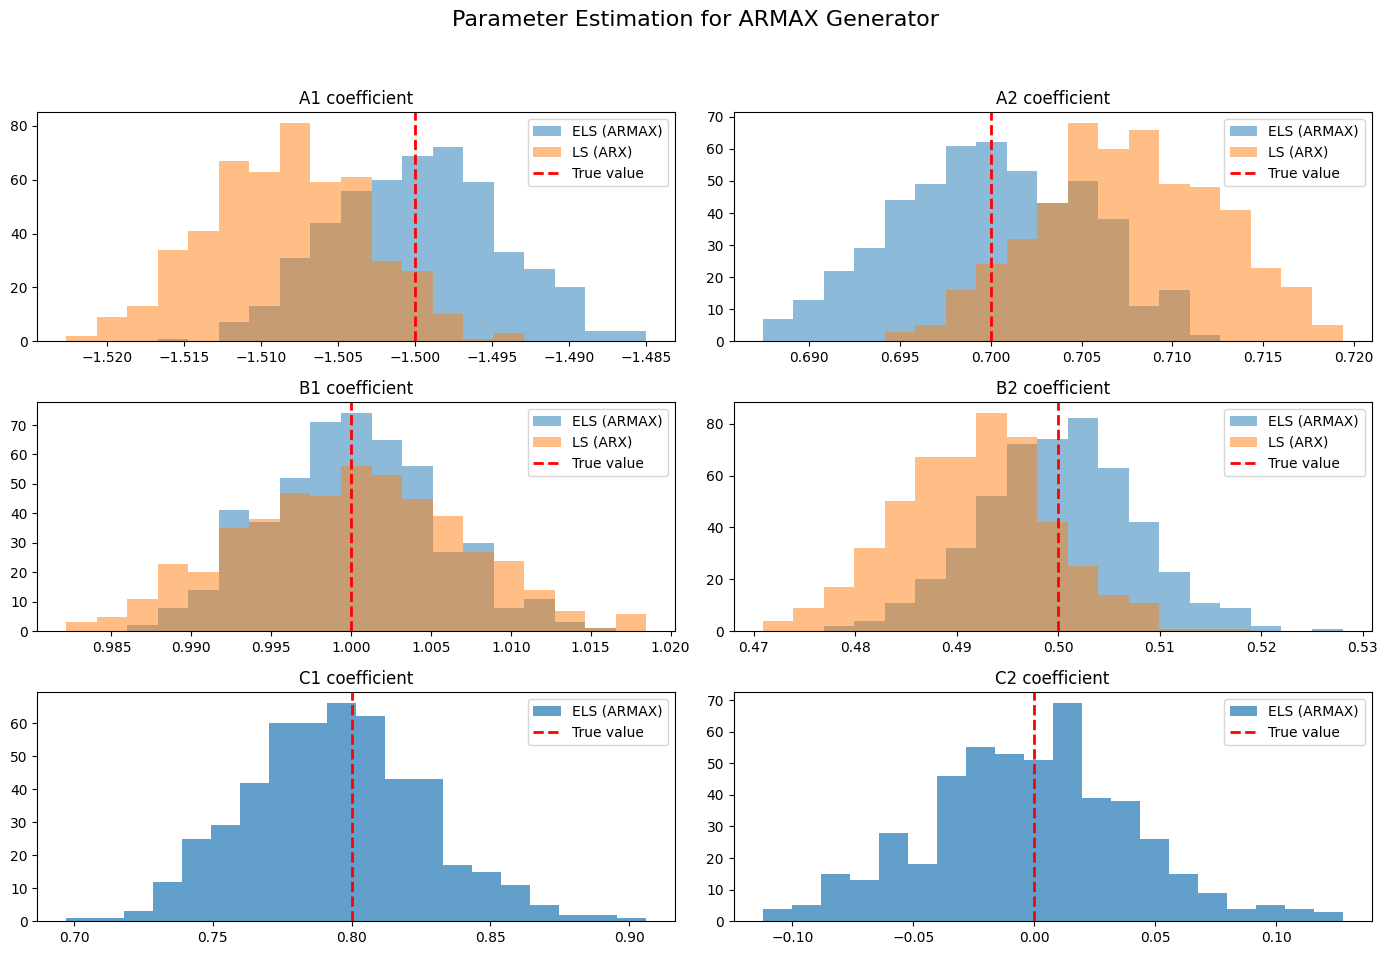

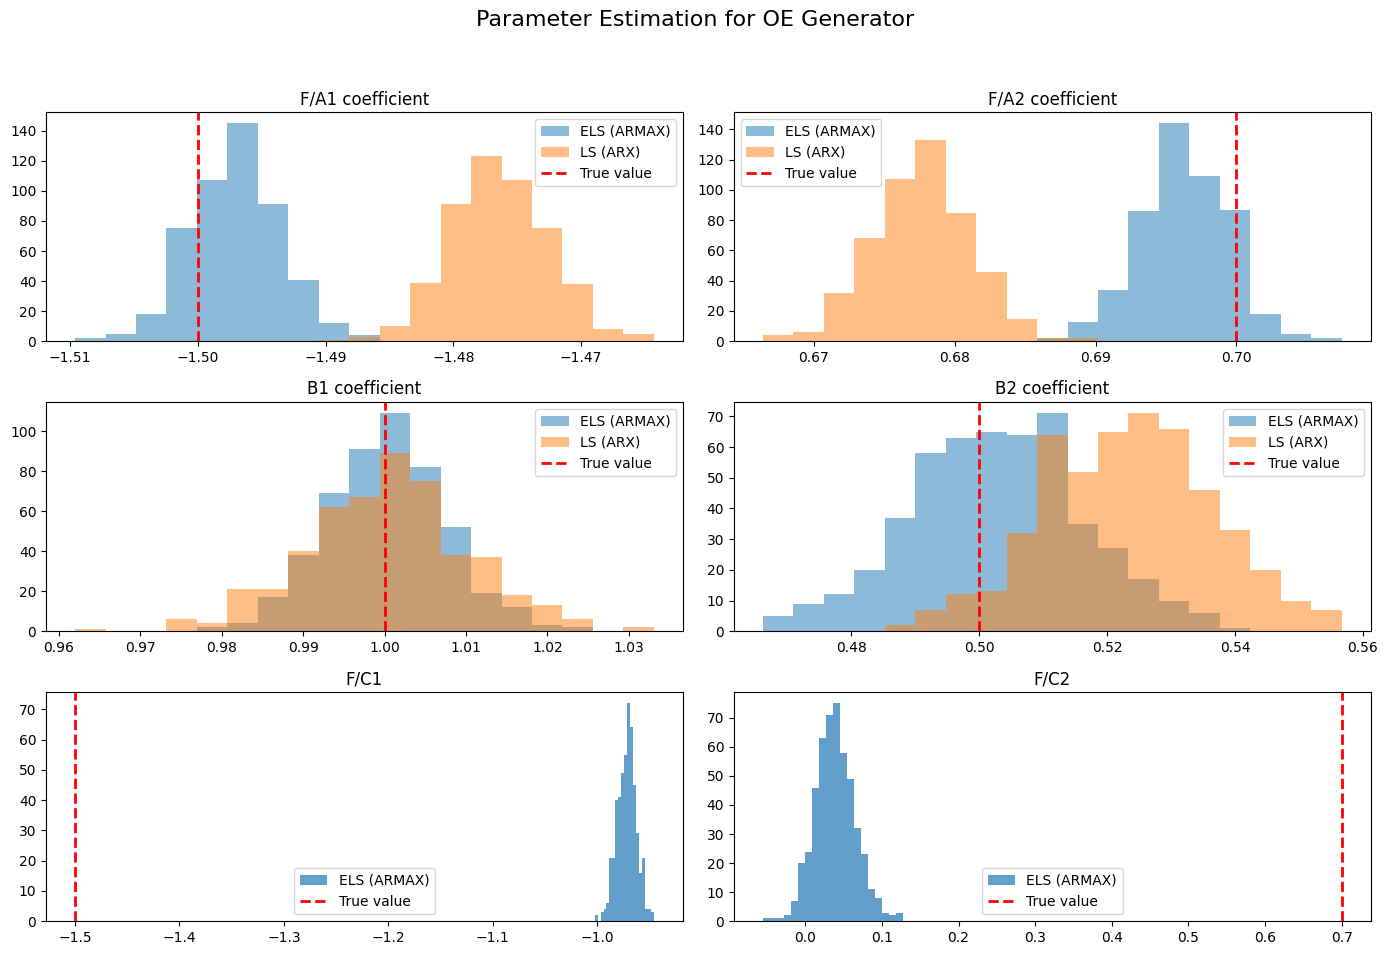

In [3]:
n_tests = 500
n_steps = 1000

# Prepare containers for results
# For ARMAX generator
ls_A_armax = np.zeros((n_tests, 2))  # A polynomial coeffs from LS (ARX)
ls_B_armax = np.zeros((n_tests, 2))  # B polynomial coeffs from LS (ARX)
# For ELS on ARMAX
els_A_armax = np.zeros((n_tests, 2))  # A polynomial coeffs from ELS (ARMAX)
els_B_armax = np.zeros((n_tests, 2))  # B polynomial coeffs from ELS (ARMAX)
els_C_armax = np.zeros((n_tests, 2))  # C polynomial coeffs from ELS (ARMAX)

# For OE generator
ls_A_oe = np.zeros((n_tests, 2))  # A polynomial coeffs from LS on OE
ls_B_oe = np.zeros((n_tests, 2))  # B polynomial coeffs from LS on OE
# For ELS on OE
els_A_oe = np.zeros((n_tests, 2))  # A polynomial coeffs from ELS on OE
els_B_oe = np.zeros((n_tests, 2))  # B polynomial coeffs from ELS on OE
els_C_oe = np.zeros((n_tests, 2))  # C polynomial coeffs from ELS on OE

for test in range(n_tests):
    u = np.random.uniform(-1, 1, n_steps)
    w = np.random.normal(0, 0.1, n_steps)

    armax_y = np.zeros(n_steps)
    oe_y = np.zeros(n_steps)

    for k in range(n_steps):
        armax_y[k] = armax(A_true, B_true, C_true, 0, u, armax_y, w, k)
        oe_y[k] = oe(F_true, B_true, 0, u, oe_y, w, k)

    # LS fits for current test
    ls_A_armax_test, ls_B_armax_test = ls(2, 2, 0, u, armax_y)
    ls_A_oe_test, ls_B_oe_test = ls(2, 2, 0, u, oe_y)

    # ELS fits for current test
    els_A_armax_test, els_B_armax_test, els_C_armax_test = els(2, 2, 2, 0, u, armax_y)
    els_A_oe_test, els_B_oe_test, els_C_oe_test = els(2, 2, 2, 0, u, oe_y)

    # Store results in the containers
    ls_A_armax[test] = ls_A_armax_test
    ls_B_armax[test] = ls_B_armax_test

    els_A_armax[test] = els_A_armax_test
    els_B_armax[test] = els_B_armax_test
    els_C_armax[test] = els_C_armax_test

    ls_A_oe[test] = ls_A_oe_test
    ls_B_oe[test] = ls_B_oe_test

    els_A_oe[test] = els_A_oe_test
    els_B_oe[test] = els_B_oe_test
    els_C_oe[test] = els_C_oe_test

# For each generator model
import matplotlib.pyplot as plt

# Create figure for ARMAX generator
fig_armax, axes_armax = plt.subplots(3, 2, figsize=(14, 10))
fig_armax.suptitle("Parameter Estimation for ARMAX Generator", fontsize=16)

# A polynomial coefficients
for i in range(2):
    ax = axes_armax[0, i]
    # Compute bins for shared axis
    all_values = np.concatenate([ls_A_armax[:, i], els_A_armax[:, i]])
    min_val, max_val = all_values.min(), all_values.max()
    bin_edges = np.linspace(min_val, max_val, 20)

    # Plot both histograms together
    ax.hist(els_A_armax[:, i], bins=bin_edges, alpha=0.5, label="ELS (ARMAX)")
    ax.hist(ls_A_armax[:, i], bins=bin_edges, alpha=0.5, label="LS (ARX)")
    ax.axvline(
        A_true[i], color="r", linestyle="dashed", linewidth=2, label="True value"
    )
    ax.set_title(f"A{i+1} coefficient")
    ax.legend()

# B polynomial coefficients
for i in range(2):
    ax = axes_armax[1, i]
    # Compute bins for shared axis
    all_values = np.concatenate([ls_B_armax[:, i], els_B_armax[:, i]])
    min_val, max_val = all_values.min(), all_values.max()
    bin_edges = np.linspace(min_val, max_val, 20)

    # Plot both histograms together
    ax.hist(els_B_armax[:, i], bins=bin_edges, alpha=0.5, label="ELS (ARMAX)")
    ax.hist(ls_B_armax[:, i], bins=bin_edges, alpha=0.5, label="LS (ARX)")
    ax.axvline(
        B_true[i], color="r", linestyle="dashed", linewidth=2, label="True value"
    )
    ax.set_title(f"B{i+1} coefficient")
    ax.legend()

# C polynomial coefficients (only from ELS)
for i in range(2):
    ax = axes_armax[2, i]
    ax.hist(els_C_armax[:, i], bins=20, alpha=0.7, label="ELS (ARMAX)")
    ax.axvline(
        C_true[i], color="r", linestyle="dashed", linewidth=2, label="True value"
    )
    ax.set_title(f"C{i+1} coefficient")
    ax.legend()

plt.tight_layout(rect=(0, 0.03, 1, 0.95))

# Create figure for OE generator
fig_oe, axes_oe = plt.subplots(3, 2, figsize=(14, 10))
fig_oe.suptitle("Parameter Estimation for OE Generator", fontsize=16)

# A polynomial coefficients
for i in range(2):
    ax = axes_oe[0, i]
    # Compute bins for shared axis
    all_values = np.concatenate([ls_A_oe[:, i], els_A_oe[:, i]])
    min_val, max_val = all_values.min(), all_values.max()
    bin_edges = np.linspace(min_val, max_val, 20)

    # Plot both histograms together
    ax.hist(els_A_oe[:, i], bins=bin_edges, alpha=0.5, label="ELS (ARMAX)")
    ax.hist(ls_A_oe[:, i], bins=bin_edges, alpha=0.5, label="LS (ARX)")
    ax.axvline(
        F_true[i], color="r", linestyle="dashed", linewidth=2, label="True value"
    )
    ax.set_title(f"F/A{i+1} coefficient")
    ax.legend()

# B polynomial coefficients
for i in range(2):
    ax = axes_oe[1, i]
    # Compute bins for shared axis
    all_values = np.concatenate([ls_B_oe[:, i], els_B_oe[:, i]])
    min_val, max_val = all_values.min(), all_values.max()
    bin_edges = np.linspace(min_val, max_val, 20)

    # Plot both histograms together
    ax.hist(els_B_oe[:, i], bins=bin_edges, alpha=0.5, label="ELS (ARMAX)")
    ax.hist(ls_B_oe[:, i], bins=bin_edges, alpha=0.5, label="LS (ARX)")
    ax.axvline(
        B_true[i], color="r", linestyle="dashed", linewidth=2, label="True value"
    )
    ax.set_title(f"B{i+1} coefficient")
    ax.legend()

# C polynomial coefficients (only from ELS)
for i in range(2):
    ax = axes_oe[2, i]
    ax.hist(els_C_oe[:, i], bins=20, alpha=0.7, label="ELS (ARMAX)")
    ax.set_title(f"F/C{i+1}")
    ax.axvline(
        F_true[i], color="r", linestyle="dashed", linewidth=2, label="True value"
    )
    ax.legend()

plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()

In [5]:
def C_as_polynomial(C: np.ndarray, w: complex) -> complex:
    result = 1.0

    for i, c in enumerate(C, start=1):
        result += c * w ** (-i)

    return result


def Re_inv_C(C: np.ndarray, w: complex) -> complex:
    """Compute 1 / C(w) where C is given by its coefficients."""
    C_w = C_as_polynomial(C, w)
    if C_w == 0.0:
        raise ValueError("C(w) is zero, cannot compute inverse.")
    return (1.0 / C_w).real


ws = np.linspace(0, np.pi, 1000)
Re_inv_C_vals = np.array([Re_inv_C(C_true, np.exp(complex(0, w))) for w in ws])
print("Re{1/C(e^(jw)} >= 1/2 for all w in [0, pi]? ", np.all(Re_inv_C_vals >= 0.5))

Re{1/C(e^(jw)} >= 1/2 for all w in [0, pi]?  True


In [22]:
def covariance_matrices(N=10, sigma2=1.0):
    # White noise covariance: diagonal
    Rv = sigma2 * np.eye(N)

    # Colored noise covariance: Toeplitz tridiagonal
    a = 1.64 * sigma2  # diagonal
    b = 0.8 * sigma2  # off-diagonal
    Re = np.zeros((N, N))
    for i in range(N):
        Re[i, i] = a
        if i < N - 1:
            Re[i, i + 1] = Re[i + 1, i] = b
    return Rv, Re


def condition_number(M):
    eigvals = np.linalg.eigvalsh(M)  # symmetric matrix
    return eigvals.min() / eigvals.max()


# Example usage
N = 10
sigma2 = 1.0
Rv, Re = covariance_matrices(N, sigma2)

print("White noise covariance:\n", Rv)
print("Condition number (white):", condition_number(Rv))

print("\nColored noise covariance:\n", Re)
print("Condition number (colored):", condition_number(Re))

White noise covariance:
 [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
Condition number (white): 1.0

Colored noise covariance:
 [[1.64 0.8  0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.8  1.64 0.8  0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.8  1.64 0.8  0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.8  1.64 0.8  0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.8  1.64 0.8  0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.8  1.64 0.8  0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.8  1.64 0.8  0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.8  1.64 0.8  0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.8  1.64 0.8 ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.8  1.64]]
Condition number (colored): 0.03300945241755619
